# Penjelasan Kode Modul 2 — Pengolahan Citra Digital

In [195]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

## Import Library

Bagian ini mengimpor tiga library dengan kegunaan masing-masing yaitu:
- **NumPy (`np`)** — untuk operasi array dan matriks piksel secara efisien
- **Matplotlib (`plt`)** — untuk menampilkan citra dan histogram secara visual
- **OpenCV (`cv`)** — untuk membaca, mengkonversi, dan memproses citra

## Membaca dan Menampilkan Citra
Citra `Meledak.png` dibaca menggunakan `plt.imread()` 

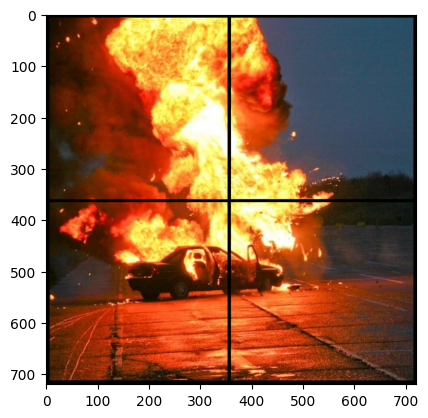

In [196]:
Meledak = plt.imread('Assets/Meledak.png')

plt.imshow(Meledak, cmap="gray")

### Pemotongan Citra (Slicing)

Citra asli dipotong menjadi **4 bagian** menggunakan slice array NumPy dengan format `[baris_awal:baris_akhir, kolom_awal:kolom_akhir]`. Keempat potongan ini kemudian ditampilkan dalam grid 2×2 menggunakan `plt.subplot`.

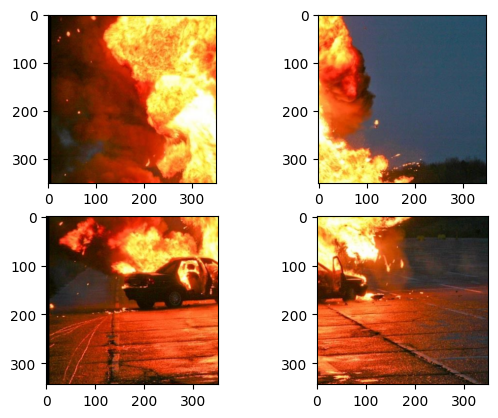

In [197]:
potong1 = Meledak[10:360,0:350]
potong2 = Meledak[10:360,360:710]

potong3 = Meledak[367:710,0:350]
potong4 = Meledak[367:710,360:710]

plt.subplot(2, 2, 1)
plt.imshow(potong1, cmap = "gray")

plt.subplot(2, 2, 2)
plt.imshow(potong2, cmap = "gray")

plt.subplot(2, 2, 3)
plt.imshow(potong3, cmap = "gray")

plt.subplot(2, 2, 4)
plt.imshow(potong4, cmap = "gray")

## 4. Fungsi Penggabungan Citra 2×2

Dua fungsi ini bekerja sama untuk menggabungkan empat potongan citra menjadi satu citra besar bersusunan 2×2:

- **`merge_horizon(citra_1, citra_2)`**
Menggabungkan dua citra secara **horizontal** (berdampingan kiri–kanan). Lebar hasil = jumlah lebar kedua citra; tinggi hasil = tinggi maksimum keduanya.

- **`merge_vertical(citra_1, citra_2)`** 
Menggabungkan dua citra secara **vertikal** (bertumpuk atas–bawah). Tinggi hasil = jumlah tinggi kedua citra; lebar hasil = lebar maksimum keduanya.

Penggunaan `dtype=citra_1.dtype` memastikan tipe data piksel (misal `float32`) tidak berubah saat proses penggabungan, sehingga gambar tidak rusak.


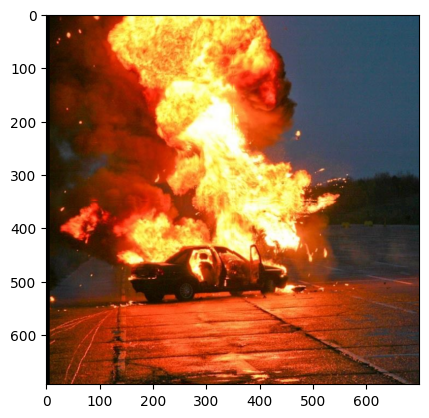

In [215]:

def merge_horizon(citra_1, citra_2):
    citra_1 = np.array(citra_1)
    citra_2 = np.array(citra_2)

    tinggi = max(citra_1.shape[0], citra_2.shape[0])
    lebar = citra_1.shape[1] + citra_2.shape[1]

    if citra_1.ndim == 3:
        hasil = np.zeros((tinggi, lebar, citra_1.shape[2]), dtype=citra_1.dtype)
    else:
        hasil = np.zeros((tinggi, lebar), dtype=citra_1.dtype)

    hasil[0:citra_1.shape[0], 0:citra_1.shape[1]] = citra_1
    hasil[0:citra_2.shape[0], citra_1.shape[1]:] = citra_2
    return hasil

def merge_vertical(citra_1, citra_2):
    citra_1 = np.array(citra_1)
    citra_2 = np.array(citra_2)

    tinggi = citra_1.shape[0] + citra_2.shape[0]
    lebar = max(citra_1.shape[1], citra_2.shape[1])

    if citra_1.ndim == 3:
        hasil = np.zeros((tinggi, lebar, citra_1.shape[2]), dtype=citra_1.dtype)
    else:
        hasil = np.zeros((tinggi, lebar), dtype=citra_1.dtype)

    hasil[0:citra_1.shape[0], 0:citra_1.shape[1]] = citra_1
    hasil[citra_1.shape[0]:, 0:citra_2.shape[1]] = citra_2
    return hasil

merged_h1 = merge_horizon(potong1, potong2)
merged_h2 = merge_horizon(potong3, potong4)
gabung_warna = merge_vertical(merged_h1, merged_h2)

plt.imshow(gabung_warna)  # tanpa cmap="gray" karena sudah berwarna

## Konversi ke Grayscale dengan OpenCV

`gabung_warna` yang masih berwarna (3D) dikonversi ke grayscale (2D) menggunakan OpenCV. Variabel `gabung_warna` tetap dipertahankan agar bisa digunakan kembali pada proses berwarna di bagian akhir. Konversi ini diperlukan agar proses histogram berikutnya bekerja pada satu channel intensitas saja.

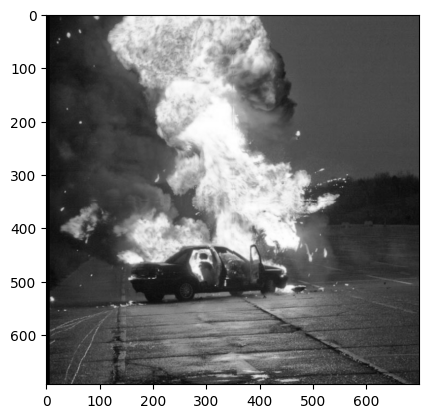

In [199]:
gabung = cv.cvtColor(gabung_warna, cv.COLOR_RGB2GRAY)
plt.imshow(gabung, cmap="gray")
plt.show()

## Fungsi Ekualisasi Histogram

Fungsi Ekualisasi Histogram digunakan untuk meningkatkan kontras citra secara otomatis dengan cara meratakan distribusi intensitas piksel. Prosesnya terdiri dari empat langkah:

1. **Hitung Histogram** — menghitung frekuensi kemunculan setiap nilai intensitas (0–255)
2. **Hitung CDF** (*Cumulative Distribution Function*) — menjumlahkan histogram secara kumulatif untuk mengetahui distribusi total piksel
3. **Normalisasi CDF** — mengubah CDF ke rentang 0–255 menggunakan rumus:
   ```
   cdf_norm = round((CDF - CDF_min) / (total_piksel - CDF_min) * 255)
   ```
4. **Pemetaan Nilai Baru** — setiap piksel pada citra asli diganti dengan nilai hasil normalisasi CDF-nya

Hasilnya adalah citra dengan kontras yang lebih merata, terutama berguna untuk citra yang terlalu gelap atau terlalu terang.

In [200]:
# Fungsi untuk ekualisasi histogram
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil


## Fungsi Hitung Histogram

Fungsi pembantu yang menghitung histogram dari sebuah gambar secara manual. Fungsi ini menangani tiga kondisi input:
- Jika citra berwarna (3 channel) → diubah ke grayscale dengan rata-rata channel
- Jika nilai piksel dalam rentang 0–1 → dikalikan 255 terlebih dahulu
- Output berupa list 256 elemen yang masing-masing menyimpan jumlah piksel per nilai intensitas

In [201]:
def hitung_histogram(gambar):
    img_arr = np.array(gambar)
    
    if len(img_arr.shape) == 3:
        img_arr = np.mean(img_arr, axis=2)
        
    if img_arr.max() <= 1.1:
        img_arr = img_arr * 255
        
    piksel_flat = img_arr.flatten().astype(int)
    
    histogram = [0] * 256
    for p in piksel_flat:
        if 0 <= p <= 255:
            histogram[p] += 1
    return histogram


## Visualisasi Sebelum dan Sesudah Ekualisasi

Citra dikonversi ke tipe `uint8` (nilai integer 0–255) sebelum diekualisasi. Hasilnya kemudian ditampilkan berdampingan untuk perbandingan visual, dilanjutkan dengan menampilkan kedua histogram (sebelum = hijau, sesudah = merah) dalam satu grafik.

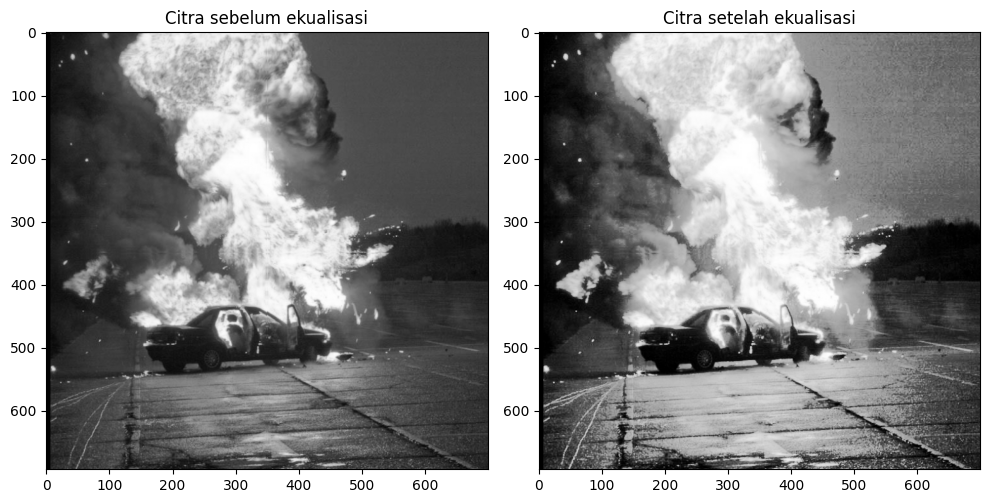

In [202]:
gabung = (gabung * 255).astype(np.uint8)

panjang, lebar = gabung.shape
hasil = ekualisasi_histogram(gabung)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gabung, cmap='gray')
plt.title("Citra sebelum ekualisasi")
plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title("Citra setelah ekualisasi")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Jumlah Pixel')

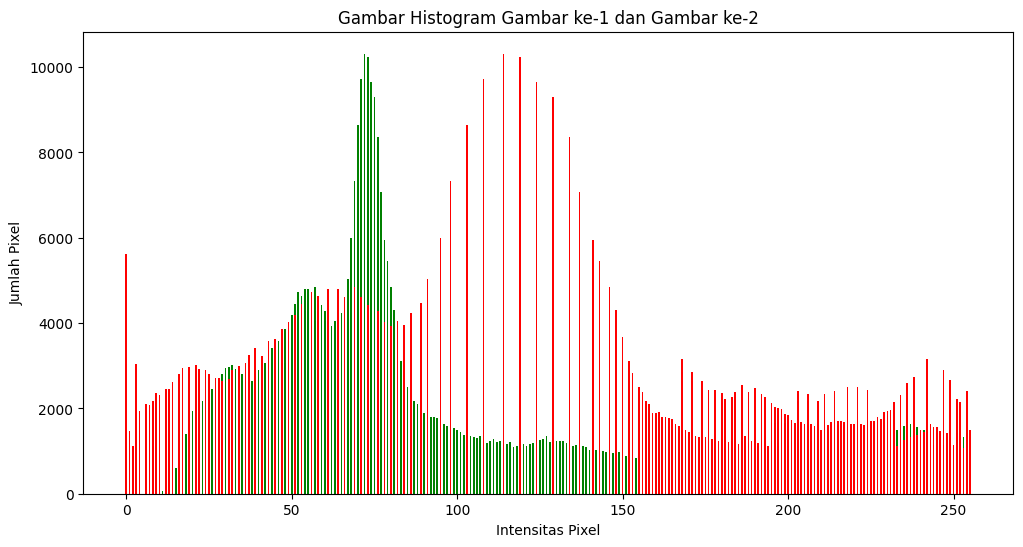

In [203]:
sebelum = hitung_histogram(gabung)
sesudah = hitung_histogram(hasil)

plt.figure(figsize=(12, 6))

plt.bar(range(256), sebelum, width=0.5, color='green') # sebelum di tambahkan atribut

plt.bar(range(256), sesudah, width=0.5, color='red') # setelah di tambahkan atribut

plt.title('Gambar Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')

## Membaca Citra Windut dan Bunga

Dua citra baru dibaca dan masing-masing dikonversi ke grayscale. `Windut` akan berperan sebagai **citra sumber** (yang akan dimodifikasi), sementara `Bunga` akan berperan sebagai **citra target** (referensi distribusi warna) pada proses spesifikasi histogram.


Text(0.5, 1.0, 'Citra Bunga Ireng')

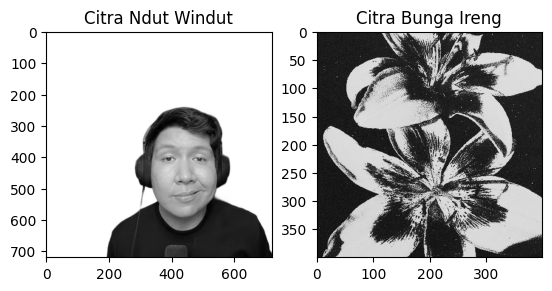

In [204]:
Windut = plt.imread('Assets/Windut.png')
Windut = cv.cvtColor(Windut,cv.COLOR_RGB2GRAY)

Bunga = plt.imread('Assets/Bunga.png')
Bunga = cv.cvtColor(Bunga,cv.COLOR_RGB2GRAY)

plt.subplot(1, 2, 1)
plt.imshow(Windut, cmap='gray')
plt.title("Citra Ndut Windut")
plt.subplot(1, 2, 2)
plt.imshow(Bunga, cmap='gray')
plt.title("Citra Bunga Ireng")



## Fungsi Spesifikasi Histogram

Fungsi Spesifikasi Histogram digunakan untuk mengubah distribusi intensitas citra sumber agar menyerupai distribusi intensitas citra target. Berbeda dengan ekualisasi yang meratakan distribusi secara seragam, spesifikasi histogram memungkinkan hasil akhir mengikuti "gaya" warna atau kecerahan citra referensi tertentu.

Langkah-langkah prosesnya:

1. **Hitung histogram** citra sumber dan target secara terpisah
2. **Hitung dan normalisasi CDF** kedua citra ke rentang 0–1
3. **Buat tabel pemetaan** — untuk setiap nilai intensitas `i` pada citra sumber, cari nilai `j` pada CDF target yang paling mendekati nilai CDF sumber di `i`:
   ```
   pemetaan[i] = argmin |CDF_target - CDF_sumber[i]|
   ```
4. **Terapkan pemetaan** ke seluruh piksel citra sumber


In [205]:
def spesifikasi_histogram(citra_sumber, citra_target):

    panjang_sumber, lebar_sumber = citra_sumber.shape
    panjang_target, lebar_target = citra_target.shape

    # Hitung histogram citra sumber & target
    histogram_sumber = np.zeros(256, dtype=int)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            histogram_sumber[nilai] += 1

    histogram_target = np.zeros(256, dtype=int)
    for i in range(panjang_target):
        for j in range(lebar_target):
            nilai = citra_target[i, j]
            histogram_target[nilai] += 1

    # Hitung CDF citra sumber & target
    cdf_sumber = np.zeros(256, dtype=int)
    for i in range(256):
        cdf_sumber[i] = np.sum(histogram_sumber[:i+1])

    cdf_sumber_min = cdf_sumber[cdf_sumber > 0].min() if np.any(cdf_sumber > 0) else 0
    cdf_sumber_norm = (cdf_sumber - cdf_sumber_min) / (panjang_sumber * lebar_sumber - cdf_sumber_min)

    cdf_target = np.zeros(256, dtype=int)
    for i in range(256):
        cdf_target[i] = np.sum(histogram_target[:i+1])

    cdf_target_min = cdf_target[cdf_target > 0].min() if np.any(cdf_target > 0) else 0
    cdf_target_norm = (cdf_target - cdf_target_min) / (panjang_target * lebar_target - cdf_target_min)

    # Mencari nilai terdekat
    pemetaan = np.zeros(256, dtype=int)
    for i in range(256):
        idx = np.argmin(np.abs(cdf_target_norm - cdf_sumber_norm[i]))
        pemetaan[i] = idx

    # Terapkan pemetaan ke citra sumber
    hasil = np.zeros_like(citra_sumber)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            hasil[i, j] = pemetaan[nilai]

    return hasil



(np.float64(-0.5), np.float64(719.5), np.float64(719.5), np.float64(-0.5))

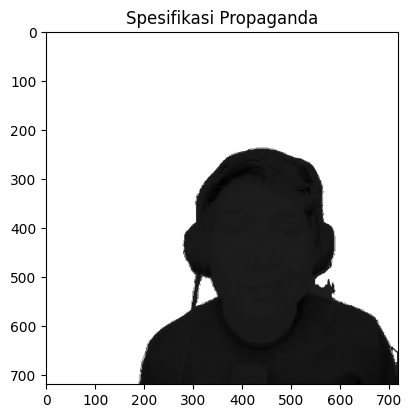

In [206]:
Windut = (Windut * 255).astype(np.uint8)
Bunga = (Bunga * 255).astype(np.uint8)


spesi = spesifikasi_histogram(Windut, Bunga)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(spesi, cmap='gray')
plt.title("Spesifikasi Propaganda")
plt.axis('on')

Hasil `spesi` adalah citra Windut yang telah disesuaikan distribusi histogramnya agar menyerupai distribusi histogram citra Bunga.

Text(0, 0.5, 'Jumlah Pixel')

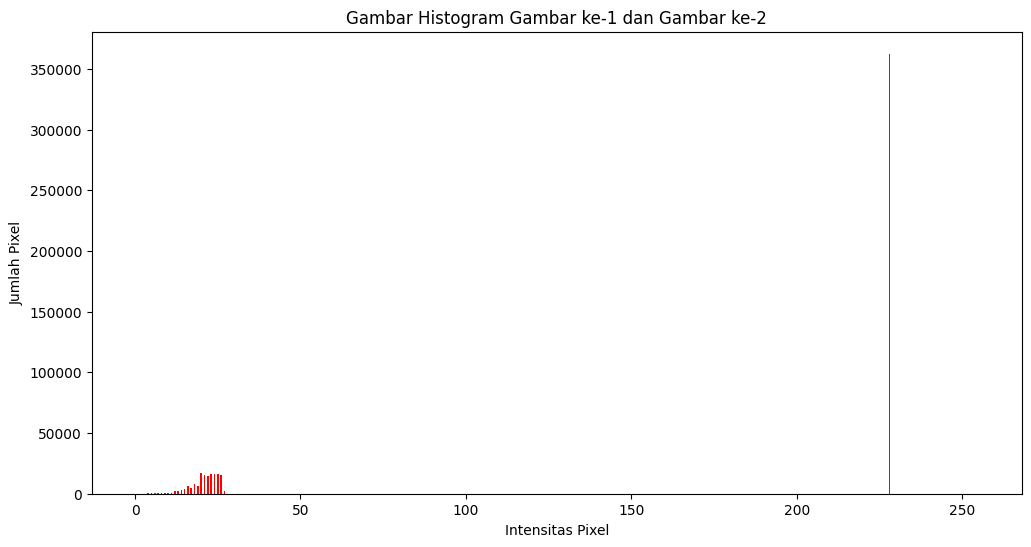

In [207]:
histo_windut = hitung_histogram(spesi)

plt.figure(figsize=(12, 6))

plt.bar(range(256), histo_windut, width=0.5, color='red')

plt.title('Gambar Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')

## Masking 

Proses masking dilakukan dengan menetapkan threshold nilai 100. Piksel dengan intensitas di atas 100 dipertahankan (mask = 1), sedangkan piksel di bawah atau sama dengan 100 diubah menjadi 0 (hitam). Ini efektif untuk memisahkan area terang dari area gelap pada citra hasil spesifikasi.


(np.float64(-0.5), np.float64(719.5), np.float64(719.5), np.float64(-0.5))

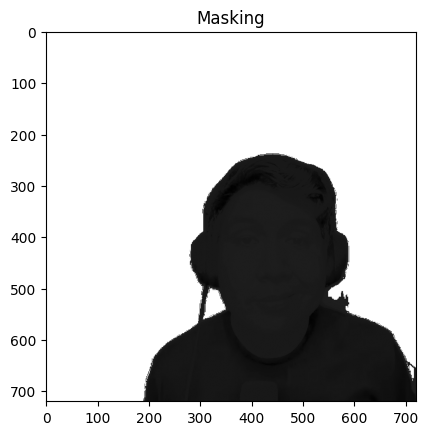

In [208]:
masking = []

height, width = spesi.shape
image_matrix = spesi

for y in range(height):
    row = []
    for x in range(width):
        if image_matrix[y][x] > 100:
            mask = 1
        else:
            mask = 0
        value = image_matrix[y][x] * mask
        row.append(value)
    masking.append(row)

plt.imshow(spesi, cmap='gray')
plt.title("Masking")
plt.axis('on')

## Fungsi-Fungsi Gabung Citra dan Perbesar Citra(versi manual)

### `copy(gambar)`
Menyalin sebuah citra grayscale piksel per piksel ke array baru menggunakan loop manual. Fungsi ini memastikan hasil yang dihasilkan adalah salinan independen, bukan referensi ke array yang sama.

### `gabungin(citra_depan, citra_belakang)`
Menggabungkan dua citra grayscale berdasarkan nilai threshold piksel:
- Piksel `> 50` pada `citra_depan` → diisi nilai dari `citra_belakang` (area ledakan)
- Piksel `≤ 50` → diisi nilai `0` (hitam)

### `perbesar(citra, tinggi_baru, lebar_baru)`
Mengubah ukuran citra ke dimensi baru menggunakan metode **Nearest Neighbor Interpolation** — setiap piksel pada citra baru dipetakan ke piksel terdekat di citra asli berdasarkan rasio skala. Fungsi ini mendukung baik citra grayscale maupun citra berwarna (RGB) melalui pengecekan `len(citra.shape) == 3`.

In [209]:
def copy(gambar):
    h, w = gambar.shape
    hasil = np.zeros((h, w), dtype=gambar.dtype)

    for i in range(h):
        for j in range(w):
            hasil[i][j] = gambar[i][j]

    return hasil

def gabungin(citra_depan, citra_belakang):
    hasil = copy(citra_depan)

    for i in range(citra_depan.shape[0]):
        for j in range(citra_depan.shape[1]):
            if citra_depan[i, j] > 50:   # area putih → tampilkan ledakan
                hasil[i, j] = citra_belakang[i, j]
            else:                         # area hitam → tetap hitam
                hasil[i, j] = 0

    return hasil

def perbesar(citra, tinggi_baru, lebar_baru):
    tinggi_asal, lebar_asal = citra.shape[:2]  # :2 agar aman untuk grayscale maupun RGB
    skala_y = tinggi_asal / tinggi_baru
    skala_x = lebar_asal / lebar_baru

    # Cek apakah citra berwarna atau grayscale
    if len(citra.shape) == 3:
        hasil = np.zeros((tinggi_baru, lebar_baru, citra.shape[2]), dtype=np.uint8)
    else:
        hasil = np.zeros((tinggi_baru, lebar_baru), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):
            y_asal = min(int(i * skala_y), tinggi_asal - 1)
            x_asal = min(int(j * skala_x), lebar_asal - 1)
            hasil[i, j] = citra[y_asal, x_asal]

    return hasil

## Penggabungan Citra Ledakan dan Ekualisasi

Citra hasil ekualisasi diperbesar ke ukuran 720×720 piksel, lalu digabungkan dengan citra `spesi` (hasil spesifikasi histogram Windut). Area terang pada `spesi` akan menampilkan tekstur dari citra ledakan yang sudah diekualisasi.


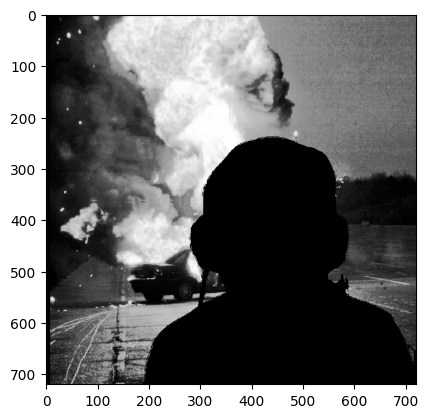

In [210]:
hasil= perbesar(hasil,720,720)

tumpuk = gabungin(spesi,hasil)

plt.imshow(tumpuk,cmap="gray")


## Fungsi `tumpuk_depan` — Kompositing Tiga Lapis (Grayscale)

Fungsi ini menggabungkan tiga citra grayscale dengan logika:
- Jika piksel pada `citra_hitam` (masker) **< 50** → tampilkan piksel dari `citra_asli` (wajah Windut)
- Jika piksel pada `citra_hitam` **≥ 50** → pertahankan piksel dari `citra_belakang` (ledakan)


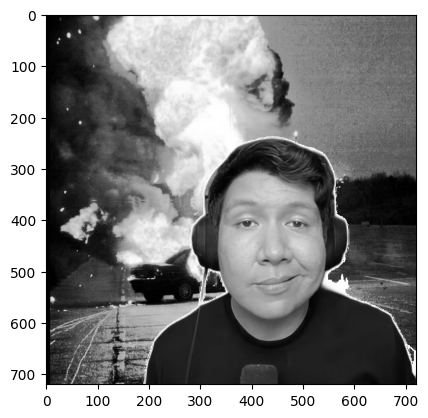

In [211]:
def tumpuk_depan(citra_hitam, citra_asli, citra_belakang):
    hasil = copy(citra_belakang)

    for i in range(citra_hitam.shape[0]):
        for j in range(citra_hitam.shape[1]):
            if citra_hitam[i, j] < 50:   # area hitam → pakai foto asli
                hasil[i, j] = citra_asli[i, j]

    return hasil

windah_gabung = tumpuk_depan(spesi, Windut, hasil)

plt.imshow(windah_gabung, cmap='gray')
plt.axis('on')
plt.show()

Hasilnya adalah citra Windut yang "ditempel" di atas citra ledakan berdasarkan area gelap masker.

## Spesifikasi Histogram dengan Target dari Citra Langit

Fungsi `spesifikasi_histogram` digunakan kembali, kali ini dengan citra langit sebagai referensi target. Tujuannya adalah mengubah distribusi intensitas citra gabungan (`windah_gabung`) agar memiliki nuansa dan kecerahan yang serupa dengan foto langit. Hasilnya divisualisasikan bersama histogram distribusi intensitasnya.


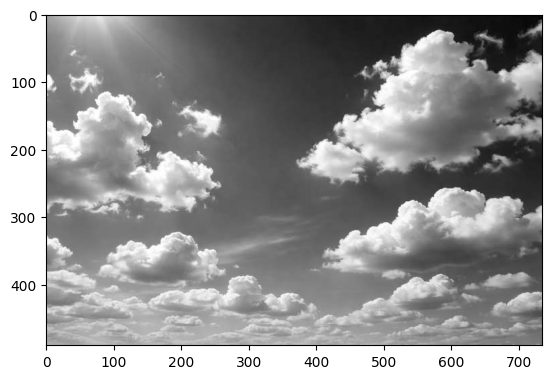

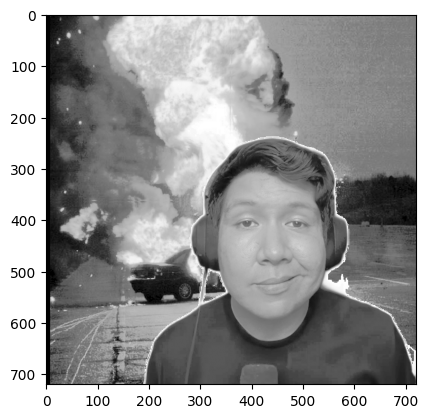

In [212]:
langitku = cv.imread('Assets/Langit.png')
langitku = cv.cvtColor(langitku,cv.COLOR_BGR2GRAY)

windut_langit = spesifikasi_histogram (windah_gabung, langitku)
plt.imshow(langitku, cmap = 'gray')
plt.show()
plt.imshow(windut_langit, cmap = 'gray')
plt.show()


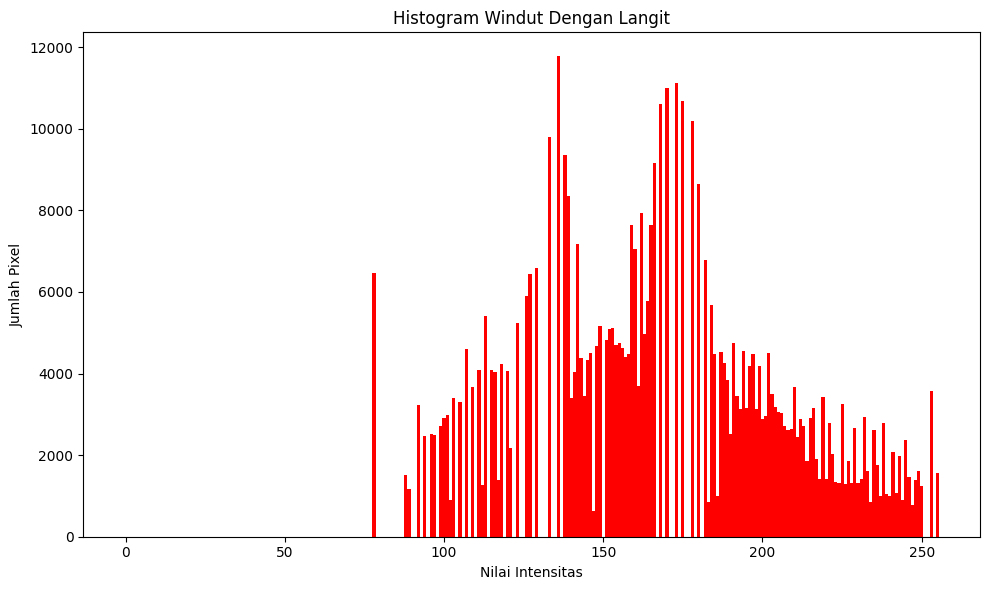

In [213]:
histogram_langit = hitung_histogram(windut_langit) # sebelum di tambahkan atribut

plt.figure(figsize=(10, 6))
plt.bar(range(256), histogram_langit, width=1, color='red') # setelah di tambahkan atribut

plt.title('Histogram Windut Dengan Langit')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

## Fungsi `tumpuk_depan2` 

Fungsi ini merupakan versi berwarna dari `tumpuk_depan`. Perbedaan utamanya adalah output berupa array 3-channel (RGB) bertipe `uint8`, sehingga warna asli dari kedua citra dipertahankan sepenuhnya.

Sebelum kompositing dilakukan, `gabung_warna` (hasil penggabungan 2×2 yang masih berwarna) dikonversi ke tipe `uint8` dan format warna BGR agar konsisten dengan citra yang dibaca oleh OpenCV. Kedua citra kemudian diperbesar ke 720×720 piksel sebelum digabungkan.


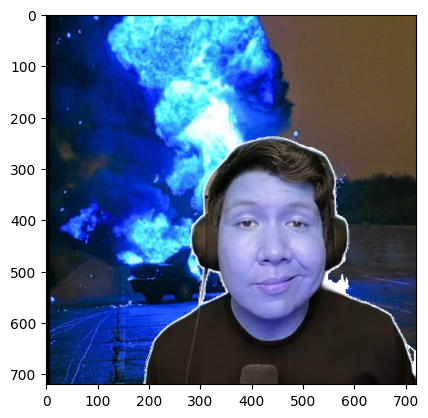

In [ ]:
def tumpuk_depan2(citra_hitam, citra_asli_color, citra_belakang_color):
    hasil = np.zeros((citra_belakang_color.shape[0], 
                    citra_belakang_color.shape[1], 3), dtype=np.uint8)

    for i in range(citra_hitam.shape[0]):
        for j in range(citra_hitam.shape[1]):
            if citra_hitam[i, j] < 50:   # area hitam → wajah berwarna
                hasil[i, j] = citra_asli_color[i, j]
            else:                         # area putih → ledakan berwarna
                hasil[i, j] = citra_belakang_color[i, j]

    return hasil

windah_color = cv.imread('Assets/Windut.png')
gabung_warna1 = np.array(gabung_warna, dtype=np.float32)
gabung_warna1 = (gabung_warna1 * 255).astype(np.uint8)

background_color = cv.cvtColor(gabung_warna1, cv.COLOR_RGB2BGR)

windah_color  = perbesar(windah_color, 720, 720)
background_color = perbesar(background_color, 720, 720)

windah_gabung = tumpuk_depan2(spesi,windah_color,background_color)

plt.imshow(windah_gabung)
plt.show()